In [30]:
import pandas as pd          # data manipulation (DataFrames)
import numpy as np           # numerical operations
import matplotlib.pyplot as plt  # plotting
from statsmodels.tsa.arima.model import ARIMA   # the ARIMA model itself
from statsmodels.tsa.stattools import adfuller  # stationarity test 
from pmdarima import auto_arima                 # automatically finds best ARIMA parameters
from sklearn.metrics import mean_absolute_error, mean_squared_error  # accuracy metrics
import warnings
warnings.filterwarnings('ignore')  # suppress noisy convergence warnings during fitting

In [31]:
# --- Load and aggregate to daily totals ---

df = pd.read_csv('solar-data-export-2026-03-17.csv', parse_dates=['timestamp'])
# Reads the CSV and immediately parses the 'timestamp' column as datetime objects

df = df.sort_values('timestamp')
# Ensures rows are in chronological order

daily = df.groupby(df['timestamp'].dt.date)['energyToday'].max()
# Groups rows by calendar date, then takes the MAX of 'energyToday' per day.
# 'energyToday' is a cumulative counter that resets each day, so the daily max
# = total energy produced that day.

daily.index = pd.to_datetime(daily.index)
# Converts the date index back to proper datetime (groupby returns plain date objects)

daily = daily[:-1]  # drop today (incomplete reading)
# Removes the last row — today's data is still accumulating, so it would
# undercount and skew the model.


In [32]:
# --- ADF Stationarity Test ---
# Null hypothesis: the series has a unit root (non-stationary)
# p < 0.05 → reject null → series IS stationary

def adf_report(series, label):
    result = adfuller(series.dropna())
    stat, p, lags, nobs, crit = result[0], result[1], result[2], result[3], result[4]
    conclusion = "STATIONARY" if p < 0.05 else "NON-STATIONARY"
    print(f"{label}")
    print(f"  ADF statistic : {stat:.4f}")
    print(f"  p-value       : {p:.4f}")
    print(f"  Lags used     : {lags}  |  Obs: {nobs}")
    print(f"  Critical values: { {k: f'{v:.3f}' for k, v in crit.items()} }")
    print(f"  => {conclusion} (p {'<' if p < 0.05 else '>='} 0.05)\n")
    return p < 0.05

is_stationary = adf_report(daily, "Original series")

if not is_stationary:
    adf_report(daily.diff(), "First-differenced series")


Original series
  ADF statistic : -0.2835
  p-value       : 0.9278
  Lags used     : 9  |  Obs: 111
  Critical values: {'1%': '-3.491', '5%': '-2.888', '10%': '-2.581'}
  => NON-STATIONARY (p >= 0.05)

First-differenced series
  ADF statistic : -7.0050
  p-value       : 0.0000
  Lags used     : 8  |  Obs: 111
  Critical values: {'1%': '-3.491', '5%': '-2.888', '10%': '-2.581'}
  => STATIONARY (p < 0.05)



In [33]:
# --- 80/20 split ---

split = int(len(daily) * 0.8)
# Calculates the index position at 80% of the data

train, test = daily[:split], daily[split:]
# train = first 80% of days, test = last 20%
# The model learns from train and is evaluated against test.

In [34]:
# --- Auto ARIMA on training data ---

auto_model = auto_arima(
    train,
    seasonal=False,   # no weekly/yearly seasonality modeled
    stepwise=True,    # uses a fast stepwise search instead of brute-force grid search
    trace=True,       # prints each candidate model's AIC score as it searches
    error_action='ignore',     # skips models that fail to converge
    suppress_warnings=True,
    max_p=5, max_q=5  # limits search space: AR lag ≤ 5, MA lag ≤ 5
)
optimal_order = auto_model.order  # e.g., (2, 1, 1)
p, d, q = optimal_order
# p = how many past values (lags) to use
# d = how many times to difference the series to make it stationary
# q = how many past forecast errors to use


Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=inf, Time=0.09 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=556.020, Time=0.01 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=490.362, Time=0.02 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=517.829, Time=0.01 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=485.074, Time=0.01 sec
 ARIMA(3,0,0)(0,0,0)[0]             : AIC=474.955, Time=0.02 sec
 ARIMA(4,0,0)(0,0,0)[0]             : AIC=471.388, Time=0.02 sec
 ARIMA(5,0,0)(0,0,0)[0]             : AIC=469.827, Time=0.03 sec
 ARIMA(5,0,1)(0,0,0)[0]             : AIC=471.469, Time=0.06 sec
 ARIMA(4,0,1)(0,0,0)[0]             : AIC=inf, Time=0.10 sec
 ARIMA(5,0,0)(0,0,0)[0] intercept   : AIC=461.166, Time=0.05 sec
 ARIMA(4,0,0)(0,0,0)[0] intercept   : AIC=459.923, Time=0.05 sec
 ARIMA(3,0,0)(0,0,0)[0] intercept   : AIC=458.800, Time=0.04 sec
 ARIMA(2,0,0)(0,0,0)[0] intercept   : AIC=458.387, Time=0.03 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=456.528, Time

In [35]:
# --- Fit and forecast ---

full_fit = ARIMA(daily, order=optimal_order).fit()
# Fits ARIMA on the FULL dataset (train + test), using the order found above.
# Fitting on all data gives better coefficient estimates.

preds = full_fit.get_prediction(start=split, dynamic=False)
# Generates predictions starting at the test split index.
# dynamic=False means each prediction uses actual past values (not prior predictions),
# so errors don't compound — this is a one-step-ahead evaluation.

pred_mean = preds.predicted_mean  # the forecasted values
ci = preds.conf_int()             # 95% confidence interval (upper and lower bounds)

In [38]:
# --- Metrics ---

mae  = mean_absolute_error(test, pred_mean)
# Average absolute difference between predicted and actual — easy to interpret in kWh

rmse = np.sqrt(mean_squared_error(test, pred_mean))
# Like MAE but penalizes large errors more heavily (squares them first)

mape = np.mean(np.abs((test - pred_mean) / test.replace(0, np.nan))) * 100
# Mean Absolute Percentage Error — expresses error as a % of actual values.
# replace(0, np.nan) avoids division by zero on days with no production.

baseline_mae = mean_absolute_error(test, [train.mean()] * len(test))
# A naive baseline: "always predict the training-set average."
# Comparing ARIMA's MAE to this shows whether the model adds real value.

print(f"ARIMA({p},{d},{q}) MAE: {mae:.2f} kWh")
print(f"ARIMA({p},{d},{q}) RMSE: {rmse:.2f} kWh")
print(f"ARIMA({p},{d},{q}) MAPE: {mape:.1f}%")
print(f'  Improvement over baseline: {(baseline_mae - mae)/baseline_mae*100:+.1f}%')
# Positive % = ARIMA beats the naive baseline.


ARIMA(0,0,1) MAE: 5.03 kWh
ARIMA(0,0,1) RMSE: 6.72 kWh
ARIMA(0,0,1) MAPE: 55.9%
  Improvement over baseline: +15.3%


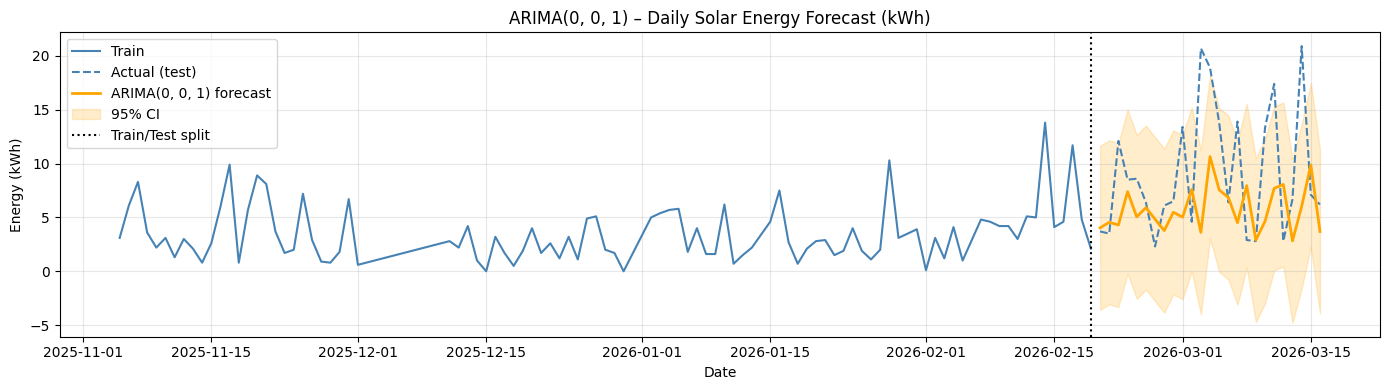

Saved: solar_arima_forecast.png


In [37]:
# --- Plot ---
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(train.index, train, label='Train', color='steelblue')
ax.plot(test.index, test, label='Actual (test)', color='steelblue', linestyle='--')
ax.plot(pred_mean.index, pred_mean, label=f'ARIMA{optimal_order} forecast', color='orange', linewidth=2)
ax.fill_between(ci.index, ci.iloc[:, 0], ci.iloc[:, 1], color='orange', alpha=0.2, label='95% CI')
ax.axvline(x=train.index[-1], color='black', linestyle=':', linewidth=1.5, label='Train/Test split')
ax.set_title(f'ARIMA{optimal_order} – Daily Solar Energy Forecast (kWh)')
ax.set_ylabel('Energy (kWh)')
ax.set_xlabel('Date')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('solar_arima_forecast.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: solar_arima_forecast.png')